Define the default font sizes to make the figures prettier:

In [1]:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

plt.rcParams.update({
    "figure.facecolor": "#0e1117",
    "axes.facecolor": "#0e1117",
    "axes.edgecolor": "#e6edf3",
    "axes.labelcolor": "#e6edf3",
    "text.color": "#e6edf3",
    "xtick.color": "#e6edf3",
    "ytick.color": "#e6edf3",
    "grid.color": "#2f3542",
    "legend.facecolor": "#161b22",
    "legend.edgecolor": "#e6edf3",
    "font.size": 12,
})
COLOR_MAP = {
    "LMS": "#58a6ff",        # bright blue
    "NLMS": "#2dd4bf",       # cyan
    "APA (P=1)": "#f472b6",  # magenta
    "APA (P=2)": "#facc15",  # yellow
    "SignError": "#a3e635",  # lime
    "SignData": "#fb7185",   # red-pink
    "SignSign": "#c084fc",   # purple
    "DualSign": "#e879f9",
    "Pow2Err": "#fb923c",
}

### 3.6.3 Channel Equalization Simulations
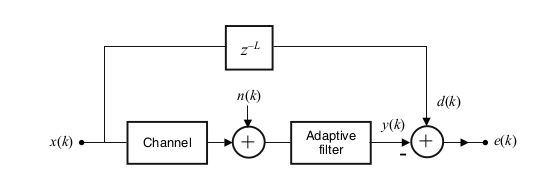

For communications perspective, the channel equalization or inverse filtering consists of estimating a transfer function to compensatefor the linear distortion caused by the channel. From another point of view, the objective is to force a prescribed dynamic behavior for the cascade of the channel (unknown system) and the adaptive filter, determined by the input signal.

In the ideal situation, where $n(k) = 0$ and the equalizer has sufficient order, the error signal is zero if both the transfer function channel $H(z)$ and adative filter $W(z)$ are inverse of each other within a possible delay $z^{-L}$ for $\delta[n-L]$ in time domain, that is :
$$W (z)H (z) = z^{−L} \quad \text{or} \quad W (z) = \frac{z^{−L}}{H (z)} $$

Example 3.7 Perform the equalization of a channel with the following impulse response: 
$$h(k) = 0.1 (0.5^k)$$

for $k = 0, 1, \ldots, 8$. Use a known training signal that consists of independent binary samples $(-1, 1)$. An additional Gaussian white noise with variance $10^{-2.5}$ is present at the channel output.

(a) Find the impulse response of an equalizer with $50$ coefficients.

(b) Convolve the equalizer impulse response at a given iteration after convergence, with the channel impulse response and comment on the result.

(a) We apply the LMS algorithm to solve the equalization problem and  measure the result to get the $\mu_{\max}$, the values of $\lambda_{\max} = 0.04275$ and $\sigma_x^2 = 0.01650$. Then apply stability condition 
$$
0 < \mu < \frac{1}{2\lambda_{\max} + \sum_{j=0}^N \lambda_j} < \frac{1}{\sum_{j=0}^N \lambda_j} = \frac{1}{\text{tr}[\mathbf{R}]}
$$
The resulting value of $\mu_{\max} = 1/\text{tr}[R] = 1.0985$ and we use $\mu = \mu_{\max} / 5 = 0.2197$ for the value of convergence factor.

In [2]:
import numpy as np
import matplotlib.pyplot as plt


# ==========================================================
# Real LMS Channel Equalizer (NumPy version)
# ==========================================================
class LMSChannelEqualizer:
    """
    Real LMS channel equalizer (NumPy version)
    """

    def __init__(self, mu: float, n_taps: int, delay: int):
        self.mu = mu
        self.n_taps = n_taps
        self.delay = delay
        self.w = np.zeros(n_taps, dtype=np.float32)

    def run(self, r, d_train, n_iter: int, train: bool = True):
        """
        Args:
            r        : channel_output_noisy
            d_train  : training sequence
            n_iter   : number of LMS iterations
        Returns:
            y_hist
            e_hist
            w_hist
        """
        w = self.w.copy()

        y_hist = np.zeros(n_iter, dtype=np.float32)
        e_hist = np.zeros(n_iter, dtype=np.float32)
        w_hist = np.zeros((n_iter, self.n_taps), dtype=np.float32)

        for k in range(n_iter):
            start_idx = k + self.delay

            # reversed regressor (same as JAX version)
            x = r[start_idx:start_idx + self.n_taps][::-1]

            y = np.dot(w, x)

            d_des = d_train[k + 2 * self.delay]
            e = d_des - y

            if train:
                w = w + 2.0 * self.mu * e * x

            y_hist[k] = y
            e_hist[k] = e
            w_hist[k] = w

        if train:
            self.w = w

        return y_hist, e_hist, w_hist

In [3]:
def runLMSEq():

    # ----------------------------------------------------------
    # Parameters
    # ----------------------------------------------------------
    N = 50
    k_range = np.arange(0, 9)
    h = 0.1 * (0.5 ** k_range)
    channel_order = len(h)

    n_iterations = 100_000
    noise_variance = 10 ** (-2.5)

    lambda_max = 0.04275
    sigma_x2 = 0.01650

    tr_R = (N + 1) * sigma_x2
    mu_max = 1.0 / tr_R
    mu = mu_max / 5.0

    print(f"mu_max = {mu_max:.6f}, using mu = {mu:.6f}")

    # ----------------------------------------------------------
    # Training signal
    # ----------------------------------------------------------
    training_length = n_iterations + N + channel_order
    training_bits = np.random.rand(training_length) > 0.5
    training_signal = (2.0 * training_bits - 1.0).astype(np.float32)

    # Channel
    channel_output = np.convolve(training_signal, h, mode="full")

    noise = np.sqrt(noise_variance) * np.random.randn(len(channel_output))
    channel_output_noisy = channel_output + noise

    delay = channel_order - 1
    print(f"Using delay = {delay}")

    max_iter_r = channel_output_noisy.shape[0] - (delay + N)
    max_iter_d = training_signal.shape[0] - 2 * delay
    n_iter = min(n_iterations, max_iter_r, max_iter_d)

    print(f"Running {n_iter} LMS iterations")

    # ----------------------------------------------------------
    # Run LMS
    # ----------------------------------------------------------
    eq = LMSChannelEqualizer(mu=mu, n_taps=N, delay=delay)
    y_hist, e_hist, w_hist = eq.run(
        channel_output_noisy.astype(np.float32),
        training_signal,
        n_iter,
        train=True
    )

    w_final = w_hist[-1]

    # ----------------------------------------------------------
    # Overall response
    # ----------------------------------------------------------
    overall_response = np.convolve(h, w_final)

    # ----------------------------------------------------------
    # MSE EMA
    # ----------------------------------------------------------
    mse_hist = np.zeros(n_iter)
    mse_hist[0] = e_hist[0] ** 2

    for k in range(1, n_iter):
        mse_hist[k] = 0.99 * mse_hist[k - 1] + 0.01 * (e_hist[k] ** 2)

    # ----------------------------------------------------------
    # Plot
    # ----------------------------------------------------------
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    axes[0, 0].stem(np.arange(N), w_final)
    axes[0, 0].set_title("(a) Equalizer Impulse Response")
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].stem(np.arange(len(overall_response)), overall_response)
    axes[0, 1].axhline(0, linestyle="--", color="red")
    axes[0, 1].set_title("(b) Overall Response h * w")
    axes[0, 1].grid(True, alpha=0.3)

    axes[1, 0].plot(10 * np.log10(mse_hist + 1e-10))
    axes[1, 0].set_title("(c) MSE Learning Curve")
    axes[1, 0].grid(True, alpha=0.3)

    last = min(1000, n_iter)
    axes[1, 1].plot(e_hist[-last:])
    axes[1, 1].set_title("(d) Error (last iterations)")
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return h, w_final, overall_response, mse_hist, e_hist

In [4]:
def plotEqCoeffs(h, w_final, overall_response):

    N = len(w_final)
    K = len(h)

    fig, axes = plt.subplots(3, 1, figsize=(12, 12))

    axes[0].stem(np.arange(N), np.abs(w_final))
    axes[0].set_title("Learned Equalizer Coefficients")
    axes[0].grid(True, alpha=0.3)

    axes[1].stem(np.arange(K), h)
    axes[1].set_title("Channel Impulse Response")
    axes[1].grid(True, alpha=0.3)

    L = len(overall_response)
    axes[2].stem(np.arange(L), overall_response)
    axes[2].axhline(0, linestyle="--", color="black")

    peak_idx = np.argmax(np.abs(overall_response))
    peak_val = overall_response[peak_idx]

    axes[2].plot(peak_idx, peak_val, "ro")
    axes[2].set_title(
        f"Overall Response (|peak| = {abs(peak_val):.3f} at index {peak_idx})"
    )
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


mu_max = 1.188354, using mu = 0.237671
Using delay = 8
Running 100000 LMS iterations


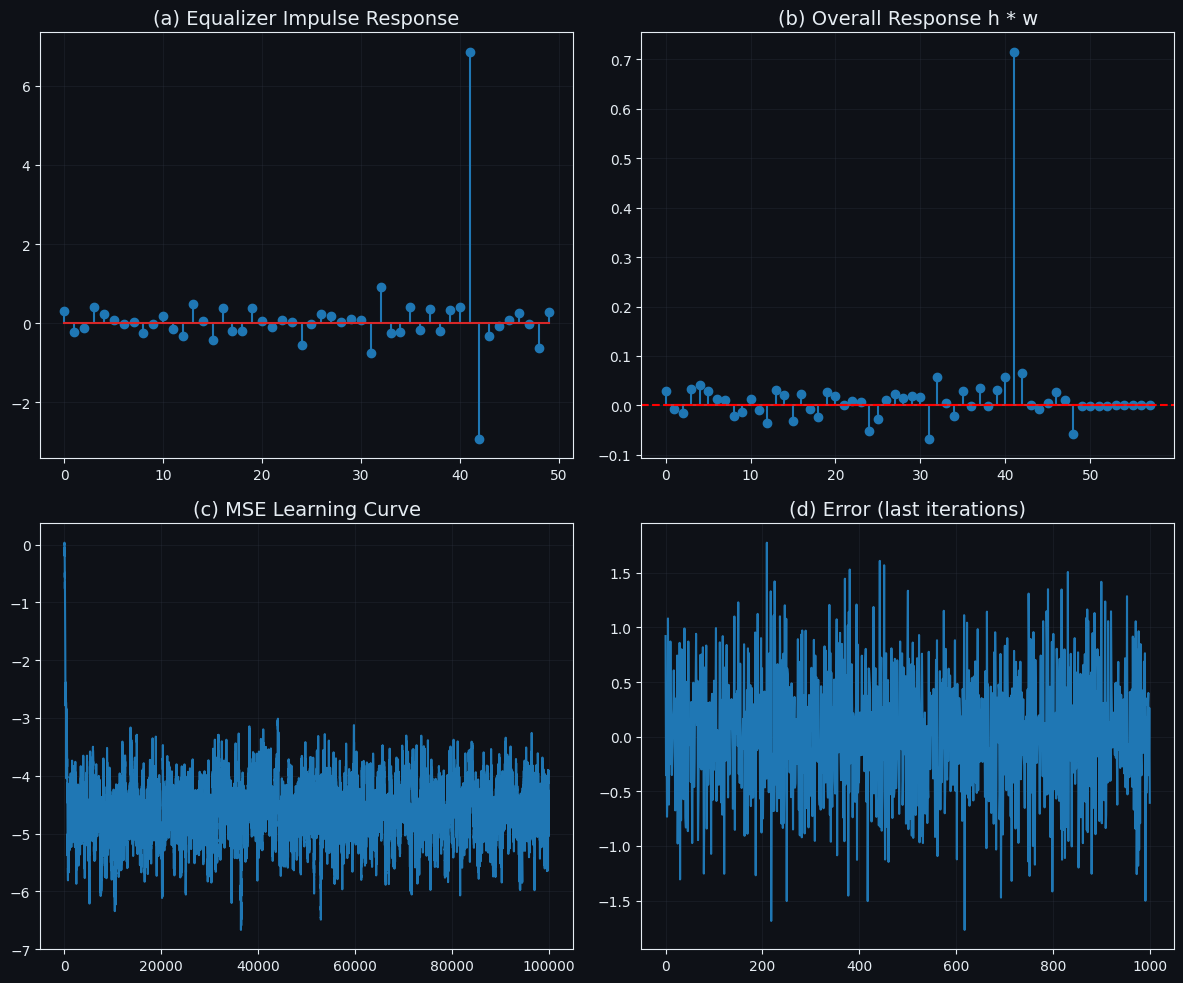

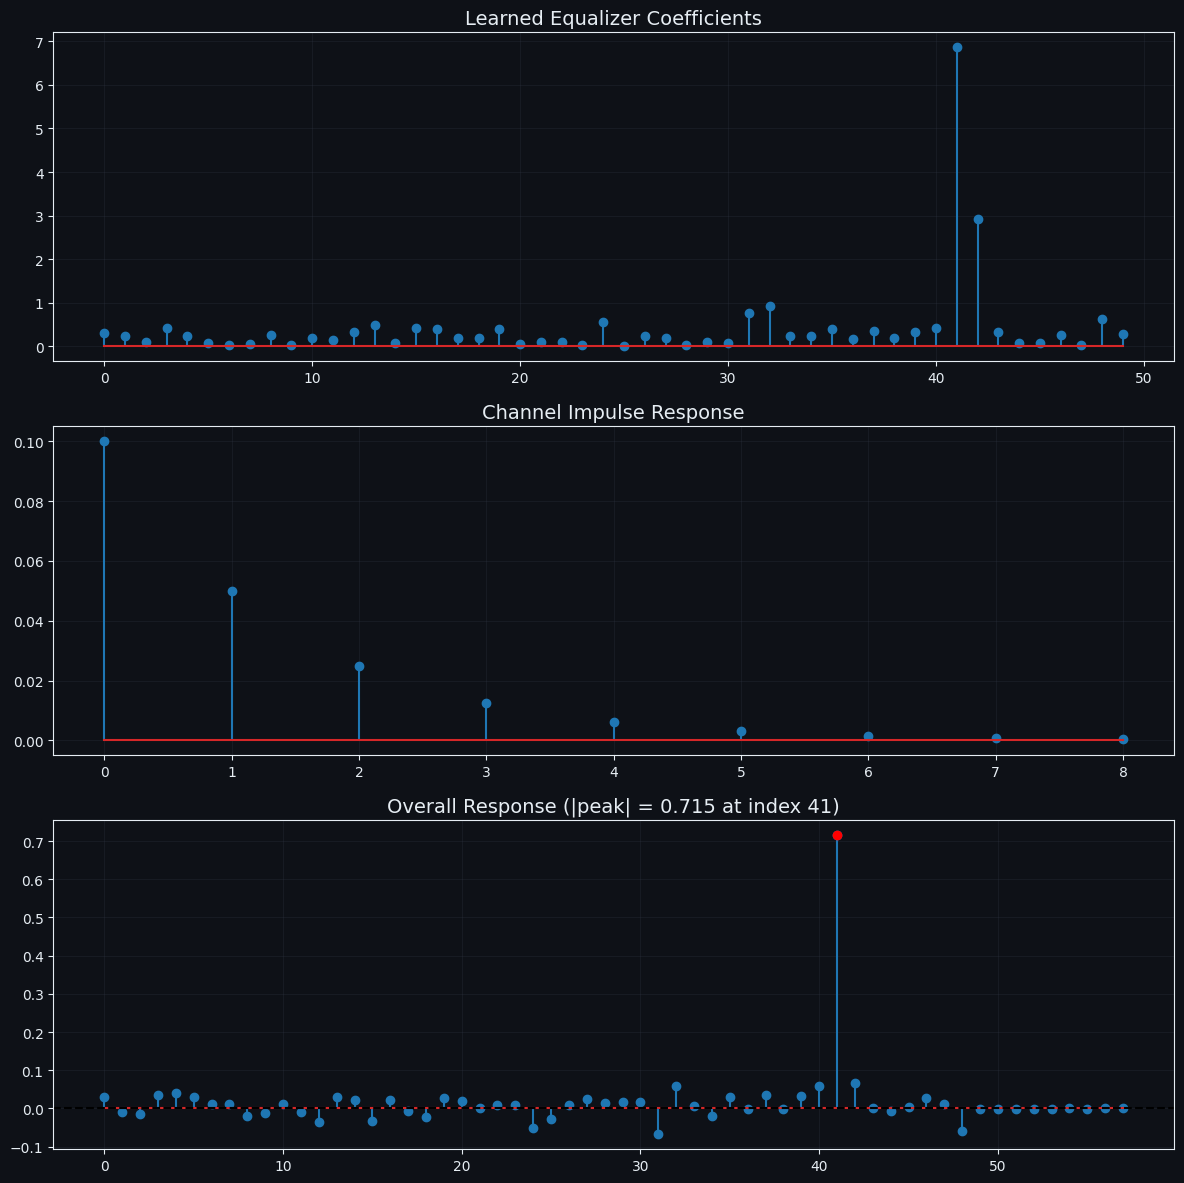

In [5]:
h, w_final, overall_resp, mse_hist, e_hist = runLMSEq()
plotEqCoeffs(h, w_final, overall_resp)